# Token Embedding 与分布式表示

> 前两节完成了 Tokenizer：文本被切成 token，每个 token 分配了一个整数编号。但编号只是编号——7 和 3 之间没有大小关系，模型无法从编号判断两个词是否相似。
>
> 这一节引入 Embedding：把离散的 token ID 映射到一个连续的向量空间。我们从「为什么需要向量」出发，逐步建立对词向量的直觉，最后组装出训练中实际使用的 Embedding 层。

Embedding 的思路是把每个 token ID 映射到一个固定长度的实数向量。同一个向量里的不同维度可以表达不同的特征——有些维度可能捕捉了"是否是动物"，有些可能捕捉了"大小"，有些可能捕捉了"抽象程度"。这些特征不是人工挑选的，而是模型在训练中自己发现的。这样一来，cat 和 dog 在大部分维度上数值接近，而 algorithm 和它们在每个维度上都相差很远——两个向量的距离直接反映了语义的远近。

## 1. 从编号到向量

为了把这个直觉变得更具体，下面用一份手工打分的表来看。假设给每个词在四个维度上打分：

| | 尺寸 | 毛茸茸 | 与人亲近 | 独立性 |
|:---|:---|:---|:---|:---|
| cat | 2 | 8 | 6 | 9 |
| dog | 5 | 9 | 9 | 3 |
| algorithm | 0 | 0 | 0 | 0 |

每一行就是一组数值，可以写成一个向量：

```text
cat       → [2, 8, 6, 9]
dog       → [5, 9, 9, 3]
algorithm → [0, 0, 0, 0]
```

维度越多，描述越细。cat 和 dog 在每个维度上都比较接近，algorithm 和它们完全不一样。Embedding 做的事情本质上是相同的——只不过这些特征不是人工挑选的，而是模型在训练过程中自己学出来的。用多个连续的数值联合描述一个 token，数值本身从数据中学来——这就是 Embedding 的核心思想。

### 从颜色 RGB 到词向量

上面用四个维度描述了 cat、dog 和 algorithm，效果比一个编号好得多。这其实就是 Embedding 的核心思路：用多个数值来描述一个东西，而不是只给它一个编号。

但有一个问题：cat 的「毛茸茸」凭什么打 8 分？「与人亲近」的衡量标准是什么？在实际的 Embedding 中，这些数值不是人定的，而是模型自己学出来的。要理解模型是怎么学的，可以先看一个生活中的例子。

颜色有两种描述方式。一种是为每种颜色起一个名字：钴蓝、胭脂红、珊瑚橙……名字越多，需要的词就越多，而且光看名字无法判断两种颜色有多接近。另一种是用 RGB 三个数值来描述，比如 (201, 23, 30)。三个数字就够了，而且判断相似性很直观——两个颜色的数值越接近，看起来就越像。(201, 23, 30) 和 (180, 20, 40) 都是红色系，(23, 180, 201) 是蓝色系，算一下数值的距离就行。

词的表示也面临同样的问题。给每个词一个编号（ID=5 是 cat，ID=12 是 dog），就像给颜色起名字——编号之间没有大小关系，也无法表达「cat 和 dog 很接近，但和 algorithm 差很远」。但如果每个词都有一个类似 RGB 的向量，词与词之间的相似性就可以直接用数值距离来衡量。

这种用多个数值描述单词的方式，叫做分布式表示（distributed representation）。和 one-hot 不同——one-hot 是一个超长的向量，10000 个词就需要 10000 维，其中只有 1 个位置是 1，其余全是 0。分布式表示只用几百维，每一维都是实数，向量之间的距离直接反映语义的远近。

但向量里的数值怎么来？不能随便填，需要从数据中学。要理解学习的过程，需要先搞清楚一件事：上下文如何决定单词的含义。

### 上下文决定含义

用向量表示单词的研究有很多。如果仔细审视这些研究，会发现几乎所有重要方法都基于一个简单的想法：某个单词的含义由它周围的单词形成。

这个想法的含义很直接。单词本身没有含义，单词的含义由它所在的上下文（语境）形成。含义相似的单词经常出现在相似的语境中。比如：

```text
I drink beer.    We drink wine.
I guzzle beer.   We guzzle wine.
```

drink 的附近常有饮料出现，guzzle 的附近也常有饮料出现——drink 和 guzzle 的上下文相似。基于这个观察，可以推断出 guzzle 和 drink 是近义词（guzzle 意为「大口喝」）。

这里所说的上下文，是指某个关注词周围的单词。上下文的大小（即周围单词的数量）称为窗口大小（window size）。窗口大小为 1，上下文包含左右各 1 个单词；窗口大小为 2，上下文包含左右各 2 个单词，以此类推。

```text
语料: You say goodbye and I say hello.

窗口大小为 2，关注词为 goodbye 时：
  You say goodbye and I say hello.
      ←──── 上下文 ────→

  goodbye 的上下文词 = {You, say, and, I}（左侧 2 个 + 右侧 2 个）
```

本节只处理左右单词数量相同、不考虑句子分隔符的情况。

In [1]:
# 共现矩阵演示：用一份迷你语料，手工构建词-上下文矩阵
# 语料就用上面介绍过的 "You say goodbye and I say hello."
corpus = "You say goodbye and I say hello ."
# 为简单起见，按空格分词，并统一小写
tokens = corpus.lower().split()
vocab = sorted(set(tokens))
V = len(vocab)

# token → index 映射
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

print(f"语料: {corpus}")
print(f"分词后: {tokens}")
print(f"词表 ({V} 个): {vocab}\n")

# 窗口大小设为 2（左右各 2 个词）
window_size = 2

# 初始化 V×V 的零矩阵，行=关注词，列=上下文词
co_matrix = [[0] * V for _ in range(V)]

# 遍历每个位置作为关注词
for center_pos in range(len(tokens)):
    center_word = tokens[center_pos]
    center_idx = word2idx[center_word]
    # 取左右各 window_size 个词作为上下文
    start = max(0, center_pos - window_size)
    end = min(len(tokens), center_pos + window_size + 1)
    for ctx_pos in range(start, end):
        if ctx_pos == center_pos:
            continue
        ctx_word = tokens[ctx_pos]
        ctx_idx = word2idx[ctx_word]
        co_matrix[center_idx][ctx_idx] += 1

# 打印共现矩阵
header = "       " + "  ".join(f"{w:>6s}" for w in vocab)
print("共现矩阵（行 = 关注词，列 = 上下文词）：")
print(header)
for i, row in enumerate(co_matrix):
    row_str = "  ".join(f"{val:6d}" for val in row)
    print(f"{idx2word[i]:>6s} | {row_str}")

print(f"\n★ 关键观察：")
print(f"  每个词由一行 {V} 维向量描述——这一行就是它的分布式表示。")
print(f"  含义相近的词（比如 say 和 goodbye 都是高频词），")
print(f"  它们在上下文中的分布模式也会趋近。")
print(f"  但问题是——词表 {V} 个词就需要 {V}×{V} = {V*V} 个计数，")
print(f"  而且每个维度只是原始频次，无法捕捉间接的语义关联。")


语料: You say goodbye and I say hello .
分词后: ['you', 'say', 'goodbye', 'and', 'i', 'say', 'hello', '.']
词表 (7 个): ['.', 'and', 'goodbye', 'hello', 'i', 'say', 'you']

共现矩阵（行 = 关注词，列 = 上下文词）：
            .     and  goodbye   hello       i     say     you
     . |      0       0       0       1       0       1       0
   and |      0       0       1       0       1       2       0
goodbye |      0       1       0       0       1       1       1
 hello |      1       0       0       0       1       1       0
     i |      0       1       1       1       0       1       0
   say |      1       2       1       1       1       0       1
   you |      0       0       1       0       0       1       0

★ 关键观察：
  每个词由一行 7 维向量描述——这一行就是它的分布式表示。
  含义相近的词（比如 say 和 goodbye 都是高频词），
  它们在上下文中的分布模式也会趋近。
  但问题是——词表 7 个词就需要 7×7 = 49 个计数，
  而且每个维度只是原始频次，无法捕捉间接的语义关联。


上面这段代码展示了一个 7×7 的共现矩阵。每一行是一个词的向量——say 这一行是 [1, 2, 1, 1, 1, 0, 1]，表示它在上下文中各遇到了几次 and、goodbye、hello 等词。这种用上下文计数来描述单词的方式，就是分布式表示最原始的形式。

共现矩阵能直观地展示「上下文相似 → 向量相似」这一思想。但它有两个明显的局限：矩阵大小是词表大小的平方（词表 10 万就是 10 万×10 万），且每个维度只是原始计数，无法捕捉更复杂的语义关系。

现代 LLM 不再使用这种基于计数的表示，而是通过训练让 Embedding 层自动学到低维密集向量。接下来我们就来看 Embedding 层的具体实现。

## 2. Embedding 查表

Embedding 的维度（通常写作 `embed_dim` 或 `d_model`）决定了每个 token 被表示成多长的向量。不同模型家族在 config.json 中用了不同的参数名，下表是常见的命名对照：

| 含义 | GPT-2 风格 | 现代模型（LLaMA / Qwen / DeepSeek / Gemma / Phi） | 论文/教学中常见 |
|:---|:---|:---|:---|
| Embedding 维度 | `n_embd` | `hidden_size` | `d_model` |
| 注意力头数 | `n_head` | `num_attention_heads` | `n_heads` |
| Transformer 层数 | `n_layer` | `num_hidden_layers` | `n_layers` |
| 词表大小 | `vocab_size` | `vocab_size` | `V` |
| FFN 中间维度 | 4 × n_embd | `intermediate_size` | `d_ff` |
| 最大序列长度 | `n_positions` | `max_position_embeddings` | `max_seq_len` |
| KV 头数（GQA） | — | `num_key_value_heads` | `n_kv_heads` |

GPT-2 是早期开源模型，它的 `n_embd` / `n_layer` / `n_head` 命名常见于 GPT-2 和 nanoGPT 等复现项目。2017 年的 Transformer 原始论文使用 `d_model` / `d_ff` 这套记号。在 HuggingFace Transformers 的公开 config 中，很多现代 decoder-only 模型（LLaMA、Qwen、Mistral、DeepSeek、Gemma、Phi）使用 `hidden_size` / `num_hidden_layers` / `num_attention_heads` 这类字段名；也会有模型家族保留自己的命名或嵌套在 `text_config` 里。读论文时遇到 `d_model`，查 HuggingFace config 时通常找 `hidden_size`，它们在这里都指贯穿残差流的模型维度。

一个容易困惑的地方：为什么 Embedding 维度在 HuggingFace 配置里叫 `hidden_size`（"隐藏层大小"），而不是 `embedding_size`？原因是 Transformer 的残差流设计——从 Embedding 层到最后输出层，层与层之间传递的主干向量维度保持一致：

```text
token ID → Embedding → [hidden_size] → Self-Attention → [hidden_size] → FFN → [hidden_size] → ... → lm_head
```

Embedding 输出 `hidden_size` 维的向量，这个向量逐层穿过 Self-Attention 和 FFN，维度始终不变，直到最后的 lm_head 才投影回词表大小。因为维度从头到尾都一样，所以 `hidden_size` 同时描述了 Embedding 的输出维度和每一层隐藏向量的维度——它们本来就是同一个数。原始 Transformer 论文把它叫做 `d_model`（model dimension），含义也是"贯穿整个模型的维度"。FFN 的中间层会临时展宽到 `intermediate_size`（通常约 4 倍），但那只是 FFN 内部的临时膨胀，输出仍然回到 `hidden_size`。

下面整理了主流模型的 Embedding 配置，模型名可点击跳转到对应的 HuggingFace config.json 验证数据：

| 模型 | 词表大小 | Embedding 维度 | Embedding 参数量 |
|:---|:---|:---|:---|
| [GPT-2 small](https://huggingface.co/openai-community/gpt2/blob/main/config.json) | 50,257 | 768 | ~39M |
| [Qwen2.5 0.5B](https://huggingface.co/Qwen/Qwen2.5-0.5B/blob/main/config.json) | 151,936 | 896 | ~136M |
| [Gemma 3 1B](https://huggingface.co/unsloth/gemma-3-1b-pt/blob/main/config.json) | 262,144 | 1,152 | ~302M |
| [GPT-2 medium](https://huggingface.co/openai-community/gpt2-medium/blob/main/config.json) | 50,257 | 1,024 | ~51M |
| [Gemma 3 4B](https://huggingface.co/unsloth/gemma-3-4b-it/blob/main/config.json) | 262,208 | 2,560 | ~671M |
| [LLaMA 2 7B](https://huggingface.co/NousResearch/Llama-2-7b-hf/blob/b3ced1bf8cac12ec77f23961af1bda9f439b8113/config.json) | 32,000 | 4,096 | ~131M |
| [Mistral 7B](https://huggingface.co/mistralai/Mistral-7B-v0.1/blob/29b3489dc8f0210f34d2a4bda08ccc072cd20d09/config.json) | 32,000 | 4,096 | ~131M |
| [Qwen2.5 7B](https://huggingface.co/Qwen/Qwen2.5-7B/blob/main/config.json) | 152,064 | 3,584 | ~545M |
| [LLaMA 3 8B](https://huggingface.co/NousResearch/Meta-Llama-3-8B/blob/main/config.json) | 128,256 | 4,096 | ~525M |
| [DeepSeek V3](https://huggingface.co/deepseek-ai/DeepSeek-V3/blob/main/config.json) | 129,280 | 7,168 | ~927M |
| [LLaMA 3 70B](https://huggingface.co/NousResearch/Meta-Llama-3-70B/blob/main/config.json) | 128,256 | 8,192 | ~1,051M |
| [Qwen2.5 72B](https://huggingface.co/Qwen/Qwen2.5-72B/blob/main/config.json) | 152,064 | 8,192 | ~1,246M |

注意：Gemma 3 4B 是多模态模型，打开 config 后要看 `text_config.vocab_size` 和 `text_config.hidden_size`。其他模型的 `vocab_size` / `hidden_size` 通常在最外层；GPT-2 的 Embedding 维度字段叫 `n_embd`。

从表中可以看出几个规律：

- **词表大小差异很大**。GPT-2 的 5 万 token 词表在当时够用，现代多语言模型（Qwen、Gemma）需要 15 万-26 万 token 才能覆盖更多语言。LLaMA 和 Mistral 保守一些，保持在 3.2 万-12.8 万。
- **维度随模型规模增长**。小模型用几百维，7B 级别用 3K-4K 维，70B+ 用 7K-8K 维。维度越高，向量能容纳的信息越丰富。
- **Embedding 参数量 = vocab_size × d_model**。注意 Qwen2.5 0.5B 虽然模型总参数只有 5 亿，但因为词表大，Embedding 层就有 1.36 亿参数——占模型总参数的四分之一以上。小模型配大词表，Embedding 常常是参数大头。

`nn.Embedding` 本质是一张这样的矩阵：

```text
矩阵形状: [vocab_size, d_model]

第 0 行 → token 0 的向量
第 1 行 → token 1 的向量
第 2 行 → token 2 的向量
...
```

给 Embedding 层一个 token ID，它就取出对应那一行。这些向量一开始是随机的，训练过程中模型会不断调整它们。训练之后，经常出现在相似上下文里的词，向量会靠得更近。

In [2]:
import torch
import torch.nn as nn

# 模拟一个 mini 词表，Embedding = vocab_size × embed_dim 的矩阵
vocab = ["the", "cat", "sat", "on", "mat", "dog", "log"]
vocab_size = len(vocab)
embed_dim = 4

embedding = nn.Embedding(vocab_size, embed_dim)

print(f"词表大小: {vocab_size}, Embedding 维度: {embed_dim}")
print(f"Embedding 权重形状: {embedding.weight.shape}  ← 就是一个 {vocab_size}×{embed_dim} 矩阵")
print(f"\n前 3 行初始值（随机）:\n{embedding.weight[:3]}")

词表大小: 7, Embedding 维度: 4
Embedding 权重形状: torch.Size([7, 4])  ← 就是一个 7×4 矩阵

前 3 行初始值（随机）:
tensor([[ 0.6552,  0.4049,  1.1951,  0.6997],
        [ 0.1326,  0.7392, -0.1053,  0.4312],
        [ 0.3791, -0.8724, -2.2462,  0.1492]], grad_fn=<SliceBackward0>)


In [3]:
import torch

# 查表：给一组 token ID，取出对应的向量
sentence_ids = torch.tensor([0, 1, 2, 3, 0, 4])  # "the cat sat on the mat"
vectors = embedding(sentence_ids)                  # 查表 → [6, 4]

print(f"token IDs: {sentence_ids.tolist()}  →  {[vocab[i] for i in sentence_ids.tolist()]}")
print(f"输出形状: {vectors.shape}  ← [{len(sentence_ids)} 个 token, 每个 {embed_dim} 维]")
print()

# 逐个看
for i, (tid, vec) in enumerate(zip(sentence_ids.tolist(), vectors)):
    print(f"  位置 {i}: '{vocab[tid]}' (ID={tid}) → {vec.tolist()}")

# 关键观察：位置 0 和 4 都是 'the'，向量完全相同
# → 同一个 token 不管出现在哪个位置，查出的向量都一样
print(f"\n关键观察：位置 0 和 4 都是 token 'the'，查出的向量完全相同")
print(f"→ 同一个 token 不管出现在哪个位置，Embedding 查出来的向量都一样")
print(f"→ 模型还无法区分词的顺序——这是下一节位置编码要解决的问题")

token IDs: [0, 1, 2, 3, 0, 4]  →  ['the', 'cat', 'sat', 'on', 'the', 'mat']
输出形状: torch.Size([6, 4])  ← [6 个 token, 每个 4 维]

  位置 0: 'the' (ID=0) → [0.6552035212516785, 0.4048985540866852, 1.195139765739441, 0.699724018573761]
  位置 1: 'cat' (ID=1) → [0.13259875774383545, 0.7391718626022339, -0.10529108345508575, 0.43119731545448303]
  位置 2: 'sat' (ID=2) → [0.3791365623474121, -0.8724361062049866, -2.246216058731079, 0.14923755824565887]
  位置 3: 'on' (ID=3) → [0.5631108283996582, -0.3396805226802826, -1.0107190608978271, 0.518673300743103]
  位置 4: 'the' (ID=0) → [0.6552035212516785, 0.4048985540866852, 1.195139765739441, 0.699724018573761]
  位置 5: 'mat' (ID=4) → [0.287114679813385, 0.0973089337348938, -0.15255385637283325, -0.45731374621391296]

关键观察：位置 0 和 4 都是 token 'the'，查出的向量完全相同
→ 同一个 token 不管出现在哪个位置，Embedding 查出来的向量都一样
→ 模型还无法区分词的顺序——这是下一节位置编码要解决的问题


**Embedding 是怎么训练出来的**

向量不会凭空拥有语义——它需要从数据中学。业界有两种主要做法。

第一种是预训练词向量，以 Word2Vec 和 GloVe 为代表。思路是单独训练 Embedding，然后把它当作固定输入喂给下游模型。

以 Word2Vec 的 Skip-gram 为例：取出一个词（比如"猫"），用它的向量去预测周围窗口内的词（"坐在"、"上"、"垫"）。预测错了就调整向量。训练下来，经常出现在相似上下文里的词（猫、狗），向量就靠得更近。GloVe 的思路类似，但它不通过预测来训练，而是直接利用全局词共现统计。

这种做法的优点是 Embedding 训练一次就可以复用。缺点是 Embedding 在下游任务中是固定的，无法根据任务微调。好比先把地基打好，再往上盖楼——如果地基的位置和楼的结构不匹配，也没办法回头调整。

第二种是端到端训练，也是现代 LLM 采用的方式。Embedding 矩阵不再单独训练，而是作为模型的一部分参数，和 Transformer 的其他层一起通过反向传播统一更新。具体来说：训练时，模型拿到一批 token ID，先通过 Embedding 层查出向量，向量经过若干层 Transformer 处理后由输出层计算 loss。loss 对模型所有参数求梯度，反向传播一路传回 Embedding 层——每一行的向量值都被梯度微调了一次。这个流程和 Transformer 中间任何一层 Linear 完全一致：没有冻结，没有特殊处理，没有单独的学习率。

可以从两个角度验证。代码层面，nanoGPT（Karpathy 的 GPT-2 复现）的 `configure_optimizers` 方法将所有 `requires_grad=True` 的参数交给 AdamW，Embedding 权重作为二维矩阵照常参与 weight decay，注释里明确写了 "embeddings decay"。学术研究层面，EMNLP 2024 有一篇论文专门分析 Embedding 层在预训练中的梯度行为，结论是"token embedding 层的梯度具有最大范数"——Pre-LN 架构下浅层梯度大于深层，Embedding 作为第一层，收到的梯度反而是最强的。COLM 2025 的另一篇论文提出在 Embedding 后加 LayerNorm 来防止梯度爆炸。如果 Embedding 不参与训练，这些研究就不存在。

训练初期，向量随机分布；训练中期，同义词的向量开始靠拢；训练后期，向量空间形成符合语言统计规律的结构。这不是预先设计好的，而是梯度一次次微调的自然结果。

注意一种容易混淆的情况：这里讨论的是 LLM 内部的 Embedding 层——一张 [vocab_size, d_model] 的查表矩阵，输入 token ID，输出 token 向量。在检索增强生成（RAG）等场景中还会遇到 BGE、E5、Jina Embeddings、Qwen3 Embedding 等独立的 Embedding 模型——它们是把整段文本编码成一个句子向量的完整模型，角色不同。

下面用一段可运行的代码来展示端到端训练的过程。用一个迷你 Embedding 矩阵和一层 Linear 模拟简化版 Transformer，跑几步训练，观察矩阵如何变化。

In [4]:
# 端到端训练演示：Embedding 矩阵如何通过反向传播更新
import torch
import torch.nn as nn

torch.manual_seed(42)

# 用一个迷你词表来演示
vocab_size, d_model = 10, 4
embedding = nn.Embedding(vocab_size, d_model)

# 用一层 Linear 模拟简化版的 "Transformer"
linear = nn.Linear(d_model, vocab_size, bias=False)

print("训练前的 Embedding 矩阵：")
print(embedding.weight.data)
print(f"\n形状: {embedding.weight.shape}  ← [vocab_size={vocab_size}, d_model={d_model}]")

# 构造一组假数据：4 个样本，每个样本 3 个 token
input_ids = torch.randint(0, vocab_size, (4, 3))
targets = torch.randint(0, vocab_size, (4, 3))

optimizer = torch.optim.SGD(
    list(embedding.parameters()) + list(linear.parameters()), lr=0.1
)

print(f"\ninput_ids 形状: {input_ids.shape}  ← [batch=4, seq_len=3]")
print(f"targets 形状:   {targets.shape}")
print(f"\n开始训练...\n")

for step in range(5):
    vectors = embedding(input_ids)           # [4, 3, d_model] — 查表取向量
    logits = linear(vectors)                  # [4, 3, vocab_size] — 投影到词表空间
    loss = nn.functional.cross_entropy(
        logits.view(-1, vocab_size),          # [12, vocab_size]
        targets.view(-1)                      # [12]
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"  step {step+1}: loss = {loss.item():.4f}")

print(f"\n训练后的 Embedding 矩阵：")
print(embedding.weight.data)

# 关键观察：比较训练前后同一行的变化
print(f"\n★ 关键观察：")
print(f"  Embedding 矩阵的每一行都通过梯度更新发生了变化。")
print(f"  这就是端到端训练——Embedding 作为模型参数，")
print(f"  和 Transformer 其他层一起被 loss 驱动着更新。")
print(f"  后面实现 Mini-GPT 时会看到完整的训练流程。")


训练前的 Embedding 矩阵：
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055],
        [ 0.6784, -1.2345, -0.0431, -1.6047],
        [-0.7521,  1.6487, -0.3925, -1.4036],
        [-0.7279, -0.5594, -0.7688,  0.7624],
        [ 1.6423, -0.1596, -0.4974,  0.4396],
        [-0.7581,  1.0783,  0.8008,  1.6806],
        [ 0.0349,  0.3211,  1.5736, -0.8455],
        [ 1.3123,  0.6872, -1.0892, -0.3553],
        [-1.4181,  0.8963,  0.0499,  2.2667],
        [ 1.1790, -0.4345, -1.3864, -1.2862]])

形状: torch.Size([10, 4])  ← [vocab_size=10, d_model=4]

input_ids 形状: torch.Size([4, 3])  ← [batch=4, seq_len=3]
targets 形状:   torch.Size([4, 3])

开始训练...

  step 1: loss = 2.8552
  step 2: loss = 2.7944
  step 3: loss = 2.7370
  step 4: loss = 2.6828
  step 5: loss = 2.6314

训练后的 Embedding 矩阵：
tensor([[ 1.9210,  1.4762,  0.9026, -2.1005],
        [ 0.6454, -1.1871, -0.0511, -1.5549],
        [-0.7521,  1.6487, -0.3925, -1.4036],
        [-0.7256, -0.5677, -0.7669,  0.7602],
        [ 1.6553, -0.1718, -0.5176,  0.4

## 3. 工业界的 Embedding 训练实践

前面的 nn.Embedding 查表把概念讲清楚了。但在真实的大语言模型训练中，还有几个工程决策直接影响参数效率和训练稳定性。下面逐一来看，每个话题都对照了实际开源代码中的做法。

**权重共享（Weight Tying）**

模型有两个地方会用到词表大小的矩阵。开头是 Embedding 层：输入 token ID，查表得到向量。结尾是输出层（lm_head）：输入向量，输出词表大小的 logits。两个矩阵形状相同，都是 [vocab_size, d_model]。

GPT-2 的做法是让这两个矩阵共享同一份权重——lm_head.weight 直接指向 wte.weight。这样词表多大，就省多少参数：vocab_size=50257, d_model=768 时省了约 3900 万参数。

这个技巧后来没有消失，但也不是所有大模型都会用。公开开源配置里，LLaMA 系列的默认配置通常是 `tie_word_embeddings=False`，也就是输入 Embedding 和输出 lm_head 独立；而一些小模型或参数敏感模型仍会使用 tying 来省参数。

所以更稳妥的说法是：**weight tying 是一个可选设计**。小模型常用它省参数；很多大模型会拆开两张矩阵，让输入表示和输出分类器各自学习。GPT-3 的完整权重和实现没有公开，不能把它当作确定例子。参考：[HuggingFace LLaMA config](https://huggingface.co/docs/transformers/v4.50.0/en/model_doc/llama)、[LLaMA 3.2 1B config 示例](https://meta-pytorch.org/torchtune/0.6/generated/torchtune.models.llama3_2.llama3_2_1b.html)。

**Weight decay 的作用范围**

Weight decay 是优化器在每次更新参数时额外施加的约束：先按比例缩小参数值（w ← w − lr × λ × w），再减去本轮梯度方向。等价于在 loss 中加上 λ||w||²/2 的惩罚项，对大的权重施加更大的拉回力度，防止参数绝对值发散。

一个常见的直觉是：Embedding 矩阵的每一行是一个 token 的语义向量。如果把行向量整体拉向原点（即衰减每个分量的绝对值），语义向量的"长度"就被人为缩短了——而语义不应该有强弱之分。按照这个思路，Embedding 权重似乎应该排除在 weight decay 之外。

但这个直觉缺乏实验支撑。实际开源代码的做法恰恰相反。

nanoGPT（Karpathy）的参数分组逻辑只有一条：`p.dim() >= 2` 的参与 decay。Embedding 权重形状是 [vocab_size, d_model]，是一个二维矩阵，dim=2，因此落在 decay 组内。

HuggingFace Trainer 和很多训练脚本常见的做法是排除 bias 与 LayerNorm/RMSNorm 的 weight；但参数分组本质上由训练脚本决定，不是框架强制规则。也就是说，Embedding 是否参与 weight decay 要看具体 recipe。教学里记住一个稳妥结论就够了：**bias/Norm 通常不 decay；Embedding 是否 decay 需要看参数分组代码**。参考：[HuggingFace Trainer 文档](https://huggingface.co/docs/transformers/main_classes/trainer)、[HuggingFace forum 讨论](https://discuss.huggingface.co/t/parameter-groups-and-gpt2-layernorm/4239)。

**初始化标准差**

`nn.Embedding` 的权重是一张 [vocab_size, d_model] 的矩阵，默认用 N(0, 1) 初始化——矩阵里每个元素独立地从均值为 0、方差为 1（即标准差为 1）的正态分布中抽取。每一行就是一个 token 的向量，长度等于 d_model。

以 d_model=768 为例。取其中一行 v = (x₁, x₂, ..., x₇₆₈)，每个 xᵢ ~ N(0, 1)。向量的模长（L2 范数）定义为 ||v|| = √(x₁² + x₂² + ... + x₇₆₈²)。它的计算过程是这样的：单看一个分量，对 N(0, 1) 来说 E[xᵢ²] = Var(xᵢ) = 1（均值为 0 时，平方的期望等于方差）。768 个独立分量累加，平方和的期望约为 768，因此模长落在 √768 ≈ 28 附近。

28 意味着什么？虽然每个分量大多在 −1 到 1 之间，但 768 维合在一起，向量端点到原点的距离接近 28。以 Self-Attention 为例，两个模长 28 的向量做点积，结果的方差约为 768，经过 softmax 后梯度容易饱和，不利于训练初期稳定收敛。

GPT-2 论文的做法很简单："A simple weight initialization of N(0, 0.02) was sufficient."——所有线性层和 Embedding 层的权重都用标准差 0.02 初始化，不随 d_model 变化。LLaMA 沿用了同样的思路，initializer_range 通常也是 0.02 左右。

用同样的方法算一下模长。每个分量 xᵢ ~ N(0, 0.02)，E[xᵢ²] = 0.02² = 0.0004。d_model 个独立分量累加，模长的期望为 √(d_model × 0.0004) = 0.02 × √d_model：

| 初始化方式 | d_model=768 | d_model=4096 |
|:---|:---|:---|
| N(0, 1)（PyTorch 默认） | 模长 ≈ 28 | 模长 ≈ 64 |
| N(0, 0.02)（GPT-2） | 模长 ≈ 0.55 | 模长 ≈ 1.28 |

0.02 把模长压到了 1 附近的量级，而且 d_model 从 768 变到 4096，模长只从 0.55 变到 1.28——变化幅度不大。再加上 Transformer 中每一层都有 LayerNorm，它会把激活值重新归一化到标准范围内，进一步降低了对初始化精度的要求。这就是为什么一个固定的 0.02 就能覆盖不同规模的模型。

**混合精度下的 Embedding**

用 FP16/BF16 训练可以加速计算、节省显存。PyTorch 的 AMP（Automatic Mixed Precision）对此有内置处理：

- `autocast` 会按设备、dtype 和算子策略决定哪些操作用低精度、哪些保持高精度；不要简单记成“Embedding 一定 FP32”。
- 很多混合精度训练会在优化器或训练框架里维护更高精度的参数/状态，但具体实现取决于 AMP、优化器和分布式框架。

如果使用 BF16（A100/H100 支持），动态范围与 FP32 相同，通常比 FP16 更不容易溢出。参考：[PyTorch AMP 文档](https://docs.pytorch.org/docs/stable/amp.html)。

下面的训练演示参考了 Karpathy 的 [nanoGPT](https://github.com/karpathy/nanoGPT) 项目。具体来说：参数分组逻辑（`p.dim() >= 2` 参与 weight decay）和 N(0, 0.02) 初始化都来自 [model.py](https://github.com/karpathy/nanoGPT/blob/master/model.py) 的 `configure_optimizers` 和 `_init_weights` 方法。我们从 HuggingFace 加载真实语料，构建一个 3000 词的迷你词表，训练 Embedding 模型，最后用 t-SNE 可视化训练前后词向量的分布变化。

In [5]:
# 从 HuggingFace 加载真实语料，构建词表与训练序列
# 参考 nanoGPT 数据处理流程：原始文本 → 分词 → 词频统计 → 词表 → token ID 序列

import torch
import torch.nn as nn
import re
from collections import Counter

# 首次运行请先安装：!pip install datasets -q
from datasets import load_dataset

torch.manual_seed(42)

# Step 1: 加载 wikitext-2 训练集（Wikipedia 英文语料）
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
print(f"数据集样本数: {len(dataset)}")

# Step 2: 简单分词——只提取小写英文单词
def simple_tokenize(text):
    return re.findall(r'\b[a-z]+\b', text.lower())

# Step 3: 统计词频
word_counter = Counter()
for example in dataset:
    if example["text"] and len(example["text"].strip()) > 0:
        word_counter.update(simple_tokenize(example["text"]))

print(f"语料总词数: {sum(word_counter.values()):,}")
print(f"不同词数:   {len(word_counter):,}")

# Step 4: 取最常见的词构建迷你词表
vocab_size = 3000
most_common = word_counter.most_common(vocab_size)
vocab_words = [w for w, _ in most_common]
word2idx = {w: i for i, w in enumerate(vocab_words)}
idx2word = {i: w for w, i in word2idx.items()}

print(f"词表大小: {vocab_size}")
print(f"前 20 个词: {vocab_words[:20]}")
print(f"第 200-220:  {vocab_words[200:220]}")

# Step 5: 将整个语料转为 token ID 序列（只保留词表中的词）
all_tokens = []
for example in dataset:
    if example["text"]:
        words = simple_tokenize(example["text"])
        ids = [word2idx[w] for w in words if w in word2idx]
        all_tokens.extend(ids)

print(f"\n有效 token 数: {len(all_tokens):,}")

# Step 6: 构造训练序列——GPT 的训练目标：给定前 N 个 token，预测下一个
seq_len = 12
sequences = []
for i in range(0, len(all_tokens) - seq_len - 1, seq_len // 2):
    sequences.append(all_tokens[i:i + seq_len + 1])

# 取一部分序列用于演示
n_sequences = 3000
data_tensor = torch.tensor(sequences[:n_sequences])
x_data = data_tensor[:, :seq_len]       # 输入: 前 seq_len 个 token
y_data = data_tensor[:, 1:seq_len + 1]  # 目标: 每个位置预测下一个 token

print(f"训练样本数: {n_sequences}, 每条长度: {seq_len}")
print(f"x 形状: {list(x_data.shape)}, y 形状: {list(y_data.shape)}")
print(f"\n样本示例（解码为词）:")
for i in range(2):
    in_words = [idx2word[tid.item()] for tid in x_data[i]]
    tgt_words = [idx2word[tid.item()] for tid in y_data[i]]
    print(f"  [{i}] {' '.join(in_words):60s}")
    print(f"      → 预测: {' '.join(tgt_words)}")


数据集样本数: 36718
语料总词数: 1,679,656
不同词数:   60,752
词表大小: 3000
前 20 个词: ['the', 'of', 'and', 'in', 'to', 'a', 'was', 'on', 'as', 's', 'that', 'for', 'with', 'by', 'is', 'it', 'from', 'at', 'his', 'he']
第 200-220:  ['single', 'won', 'system', 'play', 'video', 'times', 'us', 'according', 'record', 'third', 'based', 'april', 'man', 'included', 'just', 'march', 'book', 'january', 'those', 'show']

有效 token 数: 1,330,563
训练样本数: 3000, 每条长度: 12
x 形状: [3000, 12], y 形状: [3000, 12]

样本示例（解码为词）:
  [0] iii no japanese of the commonly referred to as iii outside japan
      → 预测: no japanese of the commonly referred to as iii outside japan is
  [1] referred to as iii outside japan is a role playing video game
      → 预测: to as iii outside japan is a role playing video game developed


模型参数: 192,000 (Embedding: 96,000, lm_head: 96,000)
初始标准差: 0.0200  ← N(0, 0.02)

参与 weight_decay:   192,000  ← Embedding 在这里
不参与 weight_decay: 0

可视化词 (20 个):
  数字: one, two, three, four, five
  时间: year, time, day, age, period
  地点: city, town, area, county, state
  人物: son, father, mother, wife, family
→ 训练前，相同语义组的词随机散落，没有聚集规律。
→ 下一个 cell 开始训练，观察词向量如何变化。


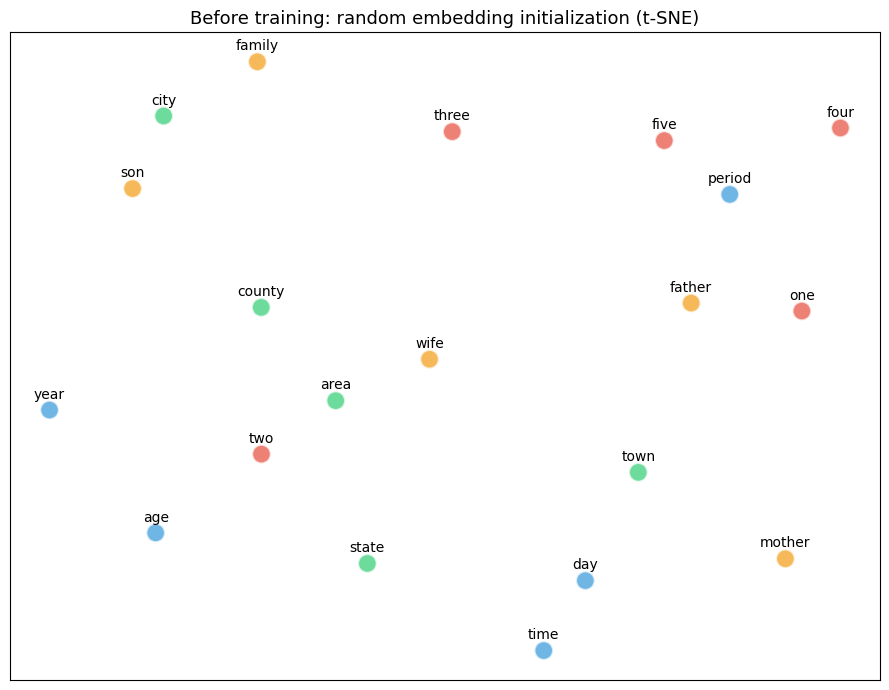

In [6]:
# 构建迷你 GPT 风格模型 + nanoGPT 参数分组 + 训练前 t-SNE 可视化

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 让 matplotlib 支持中文标签
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

embed_dim = 32

# Step 1: 定义模型——Embedding + lm_head，GPT 的最小骨架
class MiniLLM(nn.Module):
    """迷你 GPT 风格模型：Embedding → lm_head，演示 Embedding 的训练过程"""
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lm_head = nn.Linear(embed_dim, vocab_size, bias=False)
        # GPT-2/LLaMA 风格：所有权重用 N(0, 0.02) 初始化
        nn.init.normal_(self.embedding.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.lm_head.weight, mean=0.0, std=0.02)

    def forward(self, x):
        # x: [batch, seq_len] → vecs: [batch, seq_len, embed_dim]
        # → logits: [batch, seq_len, vocab_size]
        return self.lm_head(self.embedding(x))

model = MiniLLM(vocab_size, embed_dim)

total = sum(p.numel() for p in model.parameters())
print(f"模型参数: {total:,} (Embedding: {vocab_size * embed_dim:,}, "
      f"lm_head: {vocab_size * embed_dim:,})")
print(f"初始标准差: {model.embedding.weight.std().item():.4f}  ← N(0, 0.02)")

# Step 2: nanoGPT 风格参数分组——2D 矩阵参与 weight_decay
decay_params, no_decay_params = [], []
for name, param in model.named_parameters():
    if param.dim() >= 2:
        decay_params.append(param)       # Embedding、lm_head 是 2D 矩阵
    else:
        no_decay_params.append(param)    # bias、LayerNorm（本例中无）

n_decay = sum(p.numel() for p in decay_params)
n_no_decay = sum(p.numel() for p in no_decay_params)
print(f"\n参与 weight_decay:   {n_decay:,}  ← Embedding 在这里")
print(f"不参与 weight_decay: {n_no_decay:,}")

optimizer = torch.optim.AdamW([
    {'params': decay_params, 'weight_decay': 0.1},
    {'params': no_decay_params, 'weight_decay': 0.0},
], lr=0.01)

# Step 3: 选定可视化词——四组语义明确的词，观察它们训练前后的位置变化
viz_groups_def = {
    "数字": ["one", "two", "three", "four", "five"],
    "时间": ["year", "time", "day", "age", "period"],
    "地点": ["city", "town", "area", "county", "state"],
    "人物": ["son", "father", "mother", "wife", "family"],
}
color_map = {"数字": "#E74C3C", "时间": "#3498DB",
             "地点": "#2ECC71", "人物": "#F39C12"}

# 只保留在词表中实际存在的词
viz_words, viz_indices, viz_colors, viz_groups_actual = [], [], [], {}
for group_name, words in viz_groups_def.items():
    idx_list = []
    for w in words:
        if w in word2idx:
            viz_words.append(w)
            viz_indices.append(word2idx[w])
            viz_colors.append(color_map[group_name])
            idx_list.append(word2idx[w])
    if idx_list:
        viz_groups_actual[group_name] = idx_list

print(f"\n可视化词 ({len(viz_words)} 个):")
for name, idx_list in viz_groups_actual.items():
    words = [idx2word[i] for i in idx_list]
    print(f"  {name}: {', '.join(words)}")

# Step 4: 训练前 t-SNE——记录初始 Embedding 供后续对比
embeddings_before = model.embedding.weight.data[viz_indices].clone().cpu().numpy()
tsne_before = TSNE(n_components=2, random_state=42, perplexity=5)
reduced_before = tsne_before.fit_transform(embeddings_before)

fig, ax = plt.subplots(1, 1, figsize=(9, 7))
ax.scatter(reduced_before[:, 0], reduced_before[:, 1],
           c=viz_colors, s=180, alpha=0.7, edgecolors='white', linewidth=1.5)
for i, w in enumerate(viz_words):
    ax.annotate(w, (reduced_before[i, 0], reduced_before[i, 1]),
                fontsize=10, ha='center', va='bottom', xytext=(0, 6),
                textcoords='offset points')
ax.set_title("Before training: random embedding initialization (t-SNE)", fontsize=13)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()
print("→ 训练前，相同语义组的词随机散落，没有聚集规律。")
print("→ 下一个 cell 开始训练，观察词向量如何变化。")


  step   60/300: loss = 5.6641
  step  120/300: loss = 5.1485
  step  180/300: loss = 4.5539
  step  240/300: loss = 4.3058
  step  300/300: loss = 3.8567

初始 loss: 8.0065 → 最终 loss: 3.8567
loss 下降: 51.8%
→ 图已保存为 embedding_training_tsne.png

★ 定量验证：
  同组词平均余弦相似度:        0.3743
  跨组词平均余弦相似度（数字vs人物）: 0.1541
  同组 / 跨组倍数:             2.43x
  → 同组词向量确实比跨组更接近——语义结构从训练中浮现。

★ 关键观察：
  1. 左图 → 中图：同色词从散落变成聚集，Embedding 学到了语义分组。
  2. Loss 从 8.01 降到 3.86——这是真实语料上的训练信号。
  3. 整个过程没有人工标注，聚类纯粹来自「相似上下文 → 相似向量」的统计规律。


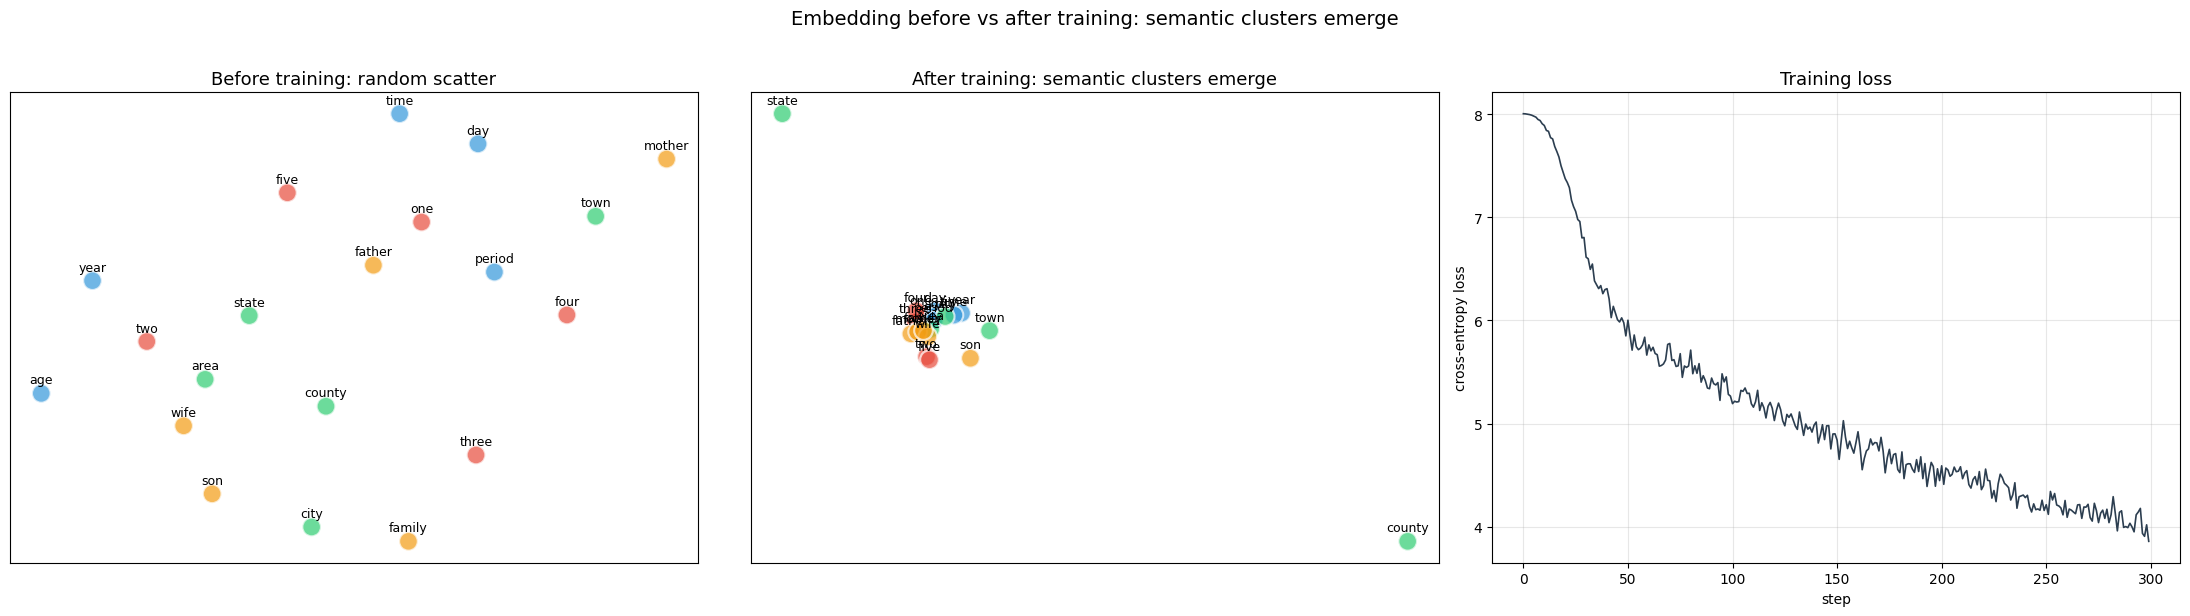

In [7]:
# 训练循环 + 训练后 t-SNE + 前后对比
# nanoGPT 风格：batch → forward → loss → backward → clip grad → step

import torch.nn.functional as F

batch_size = 64
n_steps = 300
losses = []

model.train()
for step in range(n_steps):
    # 随机采样一个 batch
    idx = torch.randint(0, n_sequences, (batch_size,))
    x_batch = x_data[idx]
    y_batch = y_data[idx]

    # Forward
    logits = model(x_batch)                      # [batch, seq_len, vocab_size]
    loss = F.cross_entropy(
        logits.reshape(-1, vocab_size),          # [batch*seq_len, vocab_size]
        y_batch.reshape(-1)                      # [batch*seq_len]
    )

    # Backward + 梯度裁剪（nanoGPT 标准做法）
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    losses.append(loss.item())
    if (step + 1) % 60 == 0:
        print(f"  step {step+1:4d}/{n_steps}: loss = {loss.item():.4f}")

print(f"\n初始 loss: {losses[0]:.4f} → 最终 loss: {losses[-1]:.4f}")
print(f"loss 下降: {(losses[0] - losses[-1]) / losses[0] * 100:.1f}%")

# Step 1: 获取训练后的 Embedding
model.eval()
with torch.no_grad():
    embeddings_after = model.embedding.weight.data[viz_indices].cpu().numpy()

# Step 2: 联合 t-SNE——将训练前后的向量拼在一起降维，确保坐标系统一
all_embeddings = np.vstack([embeddings_before, embeddings_after])
tsne_joint = TSNE(n_components=2, random_state=42, perplexity=5)
all_reduced = tsne_joint.fit_transform(all_embeddings)

n_words = len(viz_words)
reduced_before_joint = all_reduced[:n_words]
reduced_after_joint = all_reduced[n_words:]

# Step 3: 三图对比——训练前 / 训练后 / loss 曲线
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 左图：训练前
axes[0].scatter(reduced_before_joint[:, 0], reduced_before_joint[:, 1],
                c=viz_colors, s=180, alpha=0.7, edgecolors='white', linewidth=1.5)
for i, w in enumerate(viz_words):
    axes[0].annotate(w, (reduced_before_joint[i, 0], reduced_before_joint[i, 1]),
                     fontsize=9, ha='center', va='bottom', xytext=(0, 5),
                     textcoords='offset points')
axes[0].set_title("Before training: random scatter", fontsize=13)
axes[0].set_xticks([])
axes[0].set_yticks([])

# 中图：训练后
axes[1].scatter(reduced_after_joint[:, 0], reduced_after_joint[:, 1],
                c=viz_colors, s=180, alpha=0.7, edgecolors='white', linewidth=1.5)
for i, w in enumerate(viz_words):
    axes[1].annotate(w, (reduced_after_joint[i, 0], reduced_after_joint[i, 1]),
                     fontsize=9, ha='center', va='bottom', xytext=(0, 5),
                     textcoords='offset points')
axes[1].set_title("After training: semantic clusters emerge", fontsize=13)
axes[1].set_xticks([])
axes[1].set_yticks([])

# 右图：loss 曲线
axes[2].plot(range(n_steps), losses, color='#2c3e50', linewidth=1.2)
axes[2].set_title("Training loss", fontsize=13)
axes[2].set_xlabel("step")
axes[2].set_ylabel("cross-entropy loss")
axes[2].grid(True, alpha=0.3)

fig.suptitle("Embedding before vs after training: semantic clusters emerge", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("embedding_training_tsne.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ 图已保存为 embedding_training_tsne.png")

# Step 4: 定量验证——同组相似度 vs 跨组相似度
from sklearn.metrics.pairwise import cosine_similarity

emb_after = model.embedding.weight.data.cpu().numpy()

# 计算每个语义组内的平均余弦相似度
within_sims = []
for name, idx_list in viz_groups_actual.items():
    group_emb = emb_after[idx_list]
    sim_matrix = cosine_similarity(group_emb)
    triu_idx = np.triu_indices_from(sim_matrix, k=1)
    within_sims.extend(sim_matrix[triu_idx])

# 跨组：数字 vs 人物（语义差异最大）
if "数字" in viz_groups_actual and "人物" in viz_groups_actual:
    num_emb = emb_after[viz_groups_actual["数字"]]
    ppl_emb = emb_after[viz_groups_actual["人物"]]
    cross_sims = cosine_similarity(num_emb, ppl_emb).flatten()
    avg_within = np.mean(within_sims)
    avg_cross = np.mean(cross_sims)
    print(f"\n★ 定量验证：")
    print(f"  同组词平均余弦相似度:        {avg_within:.4f}")
    print(f"  跨组词平均余弦相似度（数字vs人物）: {avg_cross:.4f}")
    print(f"  同组 / 跨组倍数:             {avg_within / avg_cross:.2f}x")
    print(f"  → 同组词向量确实比跨组更接近——语义结构从训练中浮现。")

print(f"\n★ 关键观察：")
print(f"  1. 左图 → 中图：同色词从散落变成聚集，Embedding 学到了语义分组。")
print(f"  2. Loss 从 {losses[0]:.2f} 降到 {losses[-1]:.2f}——这是真实语料上的训练信号。")
print(f"  3. 整个过程没有人工标注，聚类纯粹来自「相似上下文 → 相似向量」的统计规律。")


## 小结

这一节所学的内容：

- Token ID 只是编号，不能直接作为模型的数值输入——编号的大小和语义无关
- 稠密向量用多个实数维度联合描述一个 token，维度固定（d_model），向量之间的距离直接反映语义远近
- 单词的含义由上下文决定——含义相似的词出现在相似的语境中。这是 Embedding 能学到有意义向量的理论根基
- 共现矩阵是基于计数的分布式表示，现代 LLM 改用可训练的低维稠密向量
- nn.Embedding 是一张 [vocab_size, d_model] 的可学习矩阵，查表即可取出 token 对应的向量。端到端训练中它和其他参数一起被 loss 驱动更新
- 工业界实践：weight tying 是可选设计；weight decay 要看参数分组，bias/Norm 通常排除；初始化常用 N(0, 0.02) 这类小标准差；混合精度行为取决于 AMP 和训练框架

同一个 token 不管出现在哪个位置，查出的向量都相同——模型还需要知道每个 token 在句子中的位置。下一节引入位置编码来解决这个问题。

## 作业

> 可以让 AI 帮忙解释思路，但不建议直接让 AI "做完这道题"。


**作业 1：Embedding 查表**

Token ID 本身没有语义，Embedding 会把 ID 查成向量。

小提示：`embedding_table[token_ids]` 可以一次取多行。

In [ ]:
# 作业 1：Embedding 查表填空
import torch

embedding_table = torch.tensor([
    [1.0, 0.0],  # token 0
    [0.0, 1.0],  # token 1
    [1.0, 1.0],  # token 2
])
token_ids = torch.tensor([2, 0, 1])

# TODO：把下面三引号里的内容替换成你的代码
vectors = """在这里根据 token_ids 从 embedding_table 里取出对应向量"""

assert not isinstance(vectors, str), "请先替换三引号里的占位内容"
expected = torch.tensor([[1.0, 1.0], [1.0, 0.0], [0.0, 1.0]])
assert torch.equal(vectors, expected), vectors
print("✅ 作业 1 通过：你记住了 Embedding 的核心就是查表")

In [8]:
import torch
import torch.nn as nn

# 作业 2：训练一个 mini Embedding
# 目标：亲手跑一遍训练循环，观察 Embedding 向量如何变化

torch.manual_seed(42)

vocab_size, embed_dim = 5, 2
embedding = nn.Embedding(vocab_size, embed_dim)
optimizer = torch.optim.SGD(embedding.parameters(), lr=0.5)

# 记录训练前的向量
before = embedding.weight.data.clone()

# 训练目标：让 token 0 和 token 1 的向量靠近
for step in range(20):
    vec0 = embedding(torch.tensor(0))
    vec1 = embedding(torch.tensor(1))
    
    # TODO: 构造 loss，让 vec0 和 vec1 的距离尽量小
    loss = 0.25 * (vec0 - vec1).pow(2).sum()
    
    assert not isinstance(loss, str), "请先替换占位内容"
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# 计算训练前后的距离变化
d_before = (before[0] - before[1]).pow(2).sum().item()
d_after = (embedding.weight.data[0] - embedding.weight.data[1]).pow(2).sum().item()
print(f"训练前距离: {d_before:.4f}")
print(f"训练后距离: {d_after:.4f}")
assert d_after < d_before, "训练后 token 0 和 1 的距离应该更近"
print("✅ 作业 2 通过：你亲手训练了一个 Embedding，体验了梯度如何更新向量。")

训练前距离: 0.0208
训练后距离: 0.0000
✅ 作业 2 通过：你亲手训练了一个 Embedding，体验了梯度如何更新向量。


**作业 2：训练一个 mini Embedding**

亲手跑一遍训练循环，观察 Embedding 向量如何变化。

目标：让 token 0 和 token 1 的向量靠得更近。

小提示：两个向量的距离可以用 `(vec0 - vec1).pow(2).sum()` 计算。把它当作 loss 来优化，距离就会越来越小。

**作业 3：真实 Embedding 模型 + t-SNE 可视化**

使用 HuggingFace 上的预训练 Embedding 模型，选一批语义分组明确的词，获取向量后用 t-SNE 降到 2 维可视化。观察同一语义组的词是否聚集，不同组的词是否远离。

选词分四组：动物（cat, dog, elephant, tiger）、国家（china, japan, france, germany）、食物（pizza, sushi, bread, noodle）、科技（computer, laptop, phone, tablet）。总共 16 个词，每个词用模型编码成一个稠密向量。

需要先安装依赖：

```bash
pip install sentence-transformers scikit-learn
```

小提示：`TSNE(n_components=2, random_state=42, perplexity=5)` 创建 t-SNE 对象，`fit_transform(embeddings)` 完成降维。

模型已加载，Embedding 维度: 384
Embedding 形状: (16, 384)  ← [16 个词, 每个 384 维]
→ 图已保存为 embedding_tsne.png

★ 关键观察：
  同组词平均余弦相似度:             0.5325
  跨组词平均余弦相似度 (动物 vs 科技): 0.3417
  同组 / 跨组:                       1.56x
  → 同组词的向量确实靠得更近——Embedding 捕捉到了语义相似性。
✅ 作业 3 通过：你用真实预训练 Embedding 模型验证了语义相近 = 向量相近。


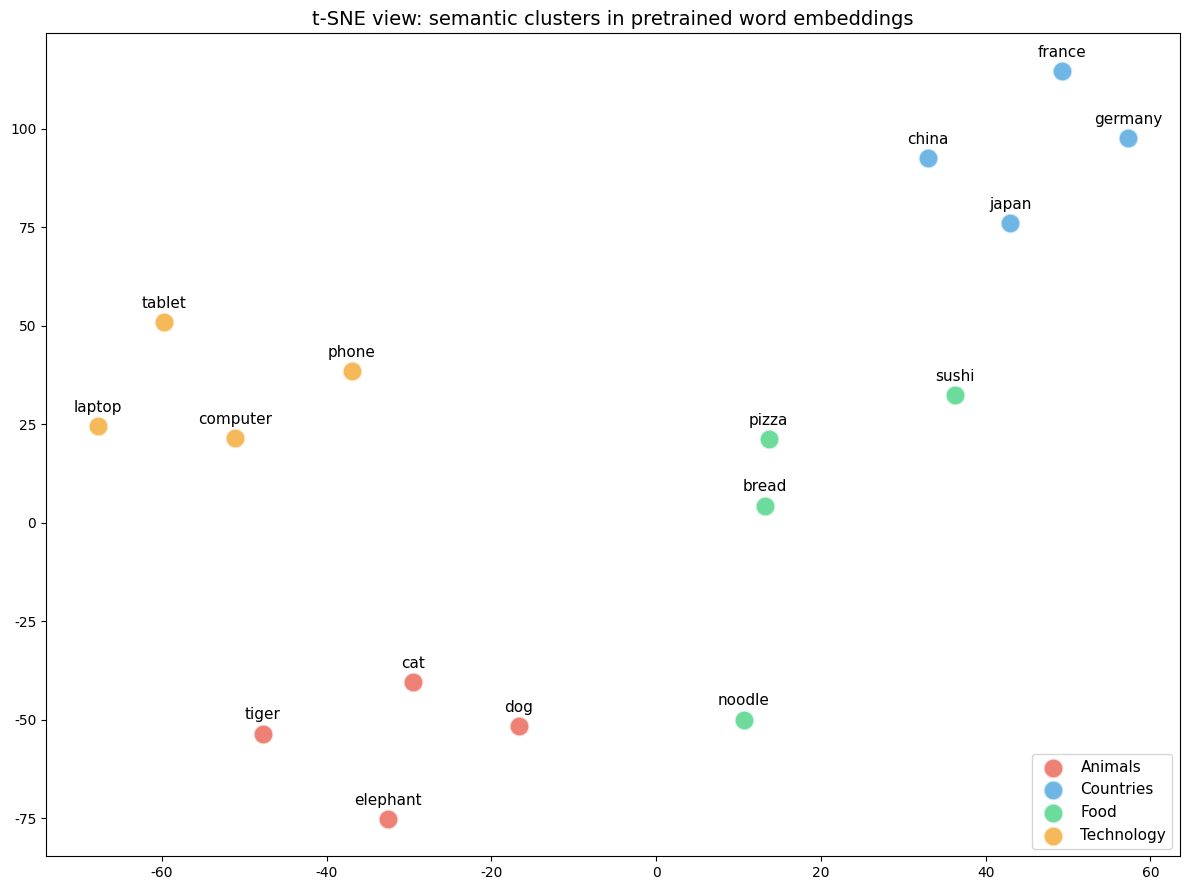

In [9]:
# 作业 3：真实 Embedding 模型 + t-SNE 可视化
# 目标：用 HuggingFace 预训练 Embedding 模型获取词向量，
# t-SNE 降维到 2D 后可视化，验证同义词聚集、异类词远离。

# 如果尚未安装依赖，取消下面两行的注释：
# !pip install sentence-transformers scikit-learn -q

import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

# Step 1: 加载 HuggingFace 预训练 Embedding 模型
# all-MiniLM-L6-v2 是一个 384 维的轻量英文模型，在 10 亿+ 句子对上训练
model = SentenceTransformer("all-MiniLM-L6-v2")
print(f"模型已加载，Embedding 维度: {model.get_sentence_embedding_dimension()}")

# Step 2: 选词——四组语义不同的词，每组内语义相近
words = [
    # 动物
    "cat", "dog", "elephant", "tiger",
    # 国家
    "china", "japan", "france", "germany",
    # 食物
    "pizza", "sushi", "bread", "noodle",
    # 科技
    "computer", "laptop", "phone", "tablet",
]
groups = {"Animals": (0, 4), "Countries": (4, 8), "Food": (8, 12), "Technology": (12, 16)}

# Step 3: 获取每个词的 Embedding 向量
embeddings = model.encode(words)
print(f"Embedding 形状: {embeddings.shape}  ← [{len(words)} 个词, 每个 {embeddings.shape[1]} 维]")

# Step 4: t-SNE 降维到 2D
# TODO: 用 TSNE 把高维 Embedding 降到 2 维平面
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
reduced = tsne.fit_transform(embeddings)

assert not isinstance(reduced, str), "请先替换三引号里的占位内容"
assert reduced.shape == (len(words), 2), \
    f"降维后形状应为 ({len(words)}, 2)，实际为 {reduced.shape}"

# Step 5: 可视化——同组同色，标注词名
colors = {"Animals": "#E74C3C", "Countries": "#3498DB", "Food": "#2ECC71", "Technology": "#F39C12"}

plt.figure(figsize=(12, 9))
for group_name, (start, end) in groups.items():
    group_words = words[start:end]
    group_points = reduced[start:end]
    plt.scatter(group_points[:, 0], group_points[:, 1],
                c=colors[group_name], s=200, alpha=0.7, label=group_name,
                edgecolors="white", linewidth=1.5)
    for word, (x, y) in zip(group_words, group_points):
        plt.annotate(word, (x, y), fontsize=11, ha="center", va="bottom",
                     xytext=(0, 8), textcoords="offset points")

plt.title("t-SNE view: semantic clusters in pretrained word embeddings", fontsize=14)
plt.legend(fontsize=11, loc="lower right")
plt.tight_layout()
plt.savefig("embedding_tsne.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ 图已保存为 embedding_tsne.png")

# Step 6: 定量验证——同组相似度 vs 跨组相似度
within_sim = []
for start, end in groups.values():
    group_emb = embeddings[start:end]
    sim_matrix = cosine_similarity(group_emb)
    # 取上三角元素（排除对角线自己和自己的相似度 1.0）
    triu_idx = np.triu_indices_from(sim_matrix, k=1)
    within_sim.extend(sim_matrix[triu_idx])

# 跨组：动物(0:4) vs 科技(12:16)
cross_sim = cosine_similarity(embeddings[0:4], embeddings[12:16]).flatten()

avg_within = np.mean(within_sim)
avg_cross = np.mean(cross_sim)

print(f"\n★ 关键观察：")
print(f"  同组词平均余弦相似度:             {avg_within:.4f}")
print(f"  跨组词平均余弦相似度 (动物 vs 科技): {avg_cross:.4f}")
print(f"  同组 / 跨组:                       {avg_within / avg_cross:.2f}x")
print(f"  → 同组词的向量确实靠得更近——Embedding 捕捉到了语义相似性。")

assert avg_within > avg_cross, \
    f"同组相似度 ({avg_within:.4f}) 应高于跨组相似度 ({avg_cross:.4f})"
print(f"✅ 作业 3 通过：你用真实预训练 Embedding 模型验证了语义相近 = 向量相近。")

## 参考资料

- Vaswani et al., [Attention Is All You Need](https://arxiv.org/abs/1706.03762), 2017 — Transformer 原始论文，Embedding 乘以 √d_model 的惯例来自此文
- Harvard NLP, [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/) — 对原始论文的逐行实现
- Mikolov et al., [Efficient Estimation of Word Representations in Vector Space](https://arxiv.org/abs/1301.3781), 2013 — Word2Vec，分布式表示的经典工作
- Karpathy, [nanoGPT](https://github.com/karpathy/nanoGPT/blob/master/model.py) — `configure_optimizers` 方法中 Embedding 权重照常参与 weight decay，是端到端训练的直接代码证据
- Chen et al., [Stable Language Model Pre-training by Reducing Embedding Variability](https://aclanthology.org/2024.emnlp-main.606.pdf), EMNLP 2024 — 从数学上推导了 token embedding 层的梯度公式，证明其梯度范数在 Pre-LN 架构下最大
- Takase et al., [Spike No More: Stabilizing the Pre-training of Large Language Models](https://openreview.net/forum?id=52YBEzcI0l), COLM 2025 — 提出在 Embedding 后加 LayerNorm 来防止梯度爆炸
- Wang et al., [Text Embeddings by Weakly-Supervised Contrastive Pre-training](https://arxiv.org/abs/2212.03533), 2022 — E5：弱监督对比预训练范式
- Xiao et al., [C-Pack: Packaged Resources To Advance General Chinese Embedding](https://arxiv.org/abs/2309.07597), 2023 — BGE：RetroMAE 预训练 + 对比微调 recipe
- Günther et al., [jina-embeddings-v3: Multilingual Embeddings With Task LoRA](https://arxiv.org/abs/2409.10173), 2024 — Jina Embeddings v3：多任务对比学习 + LoRA adapter
- Zhang et al., [Qwen3 Embedding: Advancing Text Embedding and Reranking Through Foundation Models](https://arxiv.org/abs/2506.05176), 2025 — 基于 Qwen3 基础 LLM 的三阶段 Embedding 训练
- Chen et al., [Scaling Embedding Layers in Language Models](https://arxiv.org/abs/2502.01637), NeurIPS 2025 — 大规模 Embedding 层的训练效率研究